In [1]:
import pandas as pd
df = pd.read_csv("data/TheFeatureTable.csv")

In [2]:
df.head()

,message_id,campaign_id,account_id,sender_name,recipient_id,sent_at,delivery_status,message_parts,cost,hour,is_weekend,network_provider_Provider_A,network_provider_Provider_B,network_provider_Provider_C,network_provider_Provider_D,network_provider_Unknown Provider,parts_bucket
0,MSG00017303,CMP027,ACC0135,Sender_06,9XXXXX62,2026-05-18 11:23:42+00:00,delivered,2.0,50.95,11,False,False,False,False,False,True,"(1, 2]"
1,MSG00012498,CMP029,ACC0183,Sender_02,9XXXXX30,2026-05-08 07:10:19+00:00,delivered,2.0,46.18,7,False,False,True,False,False,False,"(1, 2]"
2,MSG00021899,CMP040,ACC0172,Sender_02,9XXXXX84,2026-04-21 00:17:03+00:00,delivered,2.0,57.09,0,False,False,True,False,False,False,"(1, 2]"
3,MSG00028690,CMP020,ACC0095,Sender_06,9XXXXX97,2026-05-06 08:42:41+00:00,delivered,1.0,25.09,8,False,True,False,False,False,False,"(0, 1]"
4,MSG00014531,CMP049,ACC0155,Sender_04,9XXXXX76,2026-04-21 07:52:00+00:00,delivered,1.0,27.90,7,False,False,False,True,False,False,"(0, 1]"


In [3]:
df["failed"] = (df["delivery_status"] != "delivered").astype(int)

In [4]:
df = df.dropna(subset=["message_parts"])

In [5]:
df["cost"] = df["cost"].fillna(df["cost"].median())

In [6]:
df.head()

,message_id,campaign_id,account_id,sender_name,recipient_id,sent_at,delivery_status,message_parts,cost,hour,is_weekend,network_provider_Provider_A,network_provider_Provider_B,network_provider_Provider_C,network_provider_Provider_D,network_provider_Unknown Provider,parts_bucket,failed
0,MSG00017303,CMP027,ACC0135,Sender_06,9XXXXX62,2026-05-18 11:23:42+00:00,delivered,2.0,50.95,11,False,False,False,False,False,True,"(1, 2]",0
1,MSG00012498,CMP029,ACC0183,Sender_02,9XXXXX30,2026-05-08 07:10:19+00:00,delivered,2.0,46.18,7,False,False,True,False,False,False,"(1, 2]",0
2,MSG00021899,CMP040,ACC0172,Sender_02,9XXXXX84,2026-04-21 00:17:03+00:00,delivered,2.0,57.09,0,False,False,True,False,False,False,"(1, 2]",0
3,MSG00028690,CMP020,ACC0095,Sender_06,9XXXXX97,2026-05-06 08:42:41+00:00,delivered,1.0,25.09,8,False,True,False,False,False,False,"(0, 1]",0
4,MSG00014531,CMP049,ACC0155,Sender_04,9XXXXX76,2026-04-21 07:52:00+00:00,delivered,1.0,27.90,7,False,False,False,True,False,False,"(0, 1]",0


In [7]:
df = df.drop(columns = ["message_id", "campaign_id", "account_id", "sender_name", "recipient_id", "delivery_status", "sent_at", "parts_bucket"])

In [8]:
df.head()

,message_parts,cost,hour,is_weekend,network_provider_Provider_A,network_provider_Provider_B,network_provider_Provider_C,network_provider_Provider_D,network_provider_Unknown Provider,failed
0,2.0,50.95,11,False,False,False,False,False,True,0
1,2.0,46.18,7,False,False,True,False,False,False,0
2,2.0,57.09,0,False,False,True,False,False,False,0
3,1.0,25.09,8,False,True,False,False,False,False,0
4,1.0,27.90,7,False,False,False,True,False,False,0


In [9]:
from sklearn.model_selection import train_test_split
feature_columns = ["message_parts", "cost", "hour", "is_weekend", "network_provider_Provider_A", "network_provider_Provider_B", "network_provider_Provider_C", "network_provider_Provider_D", "network_provider_Unknown Provider"]
X= df[feature_columns]
y= df["failed"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=42)

In [10]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Train failed rate:", y_train.mean())
print("Test failed rate:", y_test.mean())

X_train shape: (23772, 9)
X_test shape: (5943, 9)
Train failed rate: 0.08459532222783106
Test failed rate: 0.08463738852431432


In [11]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

In [12]:
print("Dummy-giin accuracy:", dummy.score(X_test, y_test))

Dummy-giin accuracy: 0.9153626114756857


In [13]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

In [13]:
X_train.isna().sum()

message_parts                         0
cost                                 21
hour                                  0
is_weekend                            0
network_provider_Provider_A           0
network_provider_Provider_B           0
network_provider_Provider_C           0
network_provider_Provider_D           0
network_provider_Unknown Provider     0
dtype: int64

In [15]:
print("Dummy accuracy:", dummy.score(X_test, y_test))
print("Linear regression accuracy:", model.score(X_test, y_test))

Dummy accuracy: 0.9153626114756857
Linear regression accuracy: 0.9153626114756857


In [16]:
from sklearn.metrics import confusion_matrix
print("DCmatrix:\n", confusion_matrix(y_test, dummy.predict(X_test)))
print("LRCmatrix:\n", confusion_matrix(y_test, model.predict(X_test)))

DCmatrix:
 [[5440    0]
 [ 503    0]]
LRCmatrix:
 [[5440    0]
 [ 503    0]]


In [22]:
from sklearn.metrics import classification_report, confusion_matrix
pred = model.predict(X_test)
print(classification_report(y_test, pred, zero_division=0))
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5440
           1       0.00      0.00      0.00       503

    accuracy                           0.92      5943
   macro avg       0.46      0.50      0.48      5943
weighted avg       0.84      0.92      0.87      5943

[[5440    0]
 [ 503    0]]


AUC: 0.5988245161384633


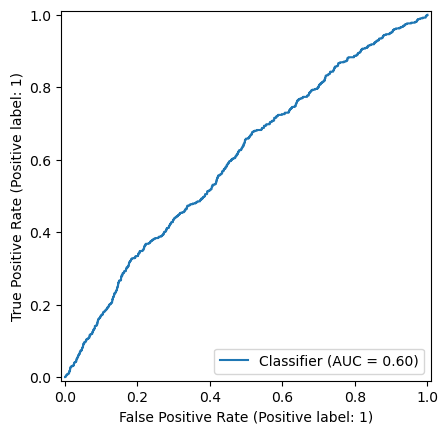

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay
proba = model.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, proba))
RocCurveDisplay.from_predictions(y_test, proba)

In [28]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print(scores.mean(), scores.std())

0.0 0.0


In [29]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(scores.mean(), scores.std())

0.600835464451794 0.019594481972361185


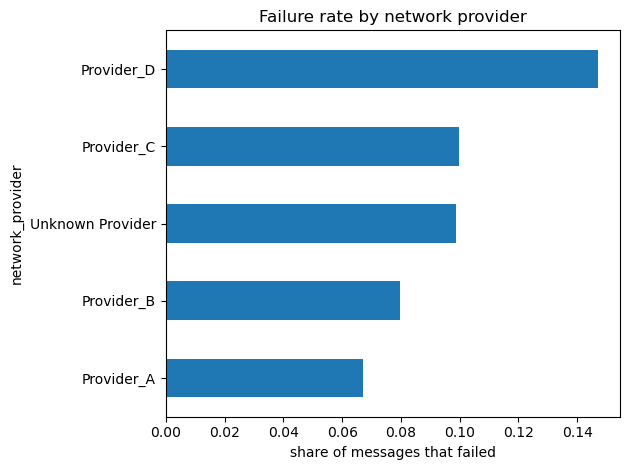

In [33]:
dff = pd.read_csv("data/clean.csv")
dff["failed"] = (dff["delivery_status"] != "delivered").astype(int)
(dff.groupby("network_provider")["failed"].mean().sort_values().plot.barh(title="Failure rate by network provider"))
plt.xlabel("share of messages that failed")
plt.tight_layout()

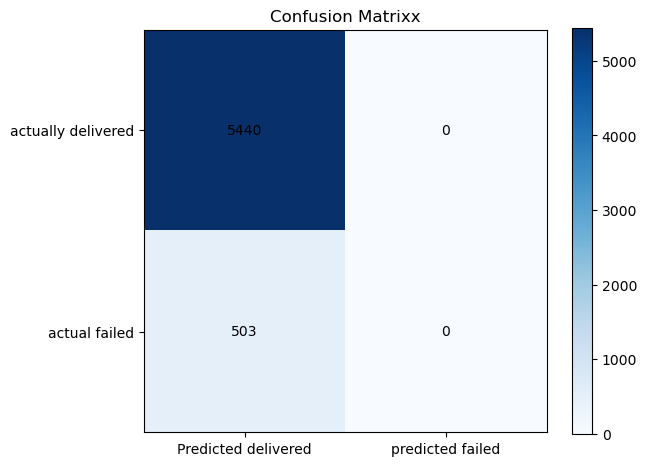

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Predicted delivered", "predicted failed"])
ax.set_yticklabels(["actually delivered", "actual failed"])
for i in range(2): 
    for j in range(2):
        ax.text(j, i, cm[i,j], ha = "center", va = "center", color="black")
ax.set_title("Confusion Matrixx")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [44]:
dff["sent_at"] = pd.to_datetime(dff["sent_at"], errors="coerce", utc=True, format="mixed")
dff["hour"] = dff["sent_at"].dt.hour
dff["is_failed"] = (dff["delivery_status"] != "delivered").astype(int)

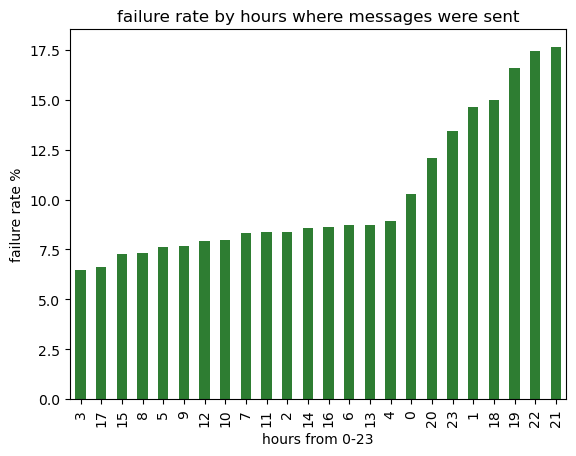

In [51]:
miss = (dff.groupby("hour")["is_failed"].mean().sort_values())*100
miss.plot(kind="bar", color="#2e7d32")
plt.title("failure rate by hours where messages were sent")
plt.ylabel("failure rate %")
plt.xlabel("hours from 0-23")
plt.show()

/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


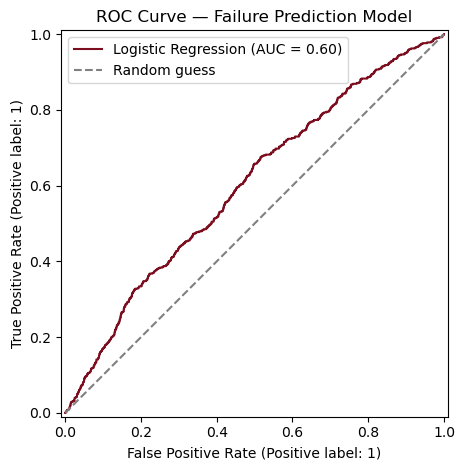

In [54]:
ax = RocCurveDisplay.from_predictions(y_test, proba, color="#7b0d1e", name="Logistic Regression").ax_
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.legend()
plt.title("ROC Curve — Failure Prediction Model")
plt.tight_layout()
plt.show()